# Coffee corpus — GloVe (Phase 1, Step 1.4)

**GloVe** (Pennington et al., 2014) learns vectors from a **global co-occurrence matrix**: how often words appear near each other in the whole corpus. That contrasts with **Word2Vec**, which predicts neighbors locally.

This notebook uses **[mittens](https://github.com/roamanalytics/mittens)** (NumPy GloVe) on the **same** `corpus.txt` as `word2vec_train.ipynb`, with the same `min_count` and `window` where possible so you can compare results.

In [1]:
%pip install -q "mittens>=0.2"

import os
import re
import subprocess
from collections import Counter, deque
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from mittens.np_mittens import GloVe
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

Note: you may need to restart the kernel to use updated packages.


## Google Colab

Same as the Word2Vec notebook: clone the repo if `corpus.txt` is missing.

In [2]:
if Path("/content").is_dir() and not os.environ.get("COFFEE_FLAVOR_MAP_ROOT"):
    _clone = Path("/content/ml-nlp-guide")
    _url = "https://github.com/YOUSEF-ysfxjo/ml-nlp-guide.git"
    _corpus = _clone / "coffee-flavor-map" / "data" / "processed" / "corpus.txt"
    if not _corpus.is_file():
        if not _clone.is_dir():
            subprocess.run(
                ["git", "clone", "--depth", "1", _url, str(_clone)],
                check=True,
                cwd="/content",
            )
        if not _corpus.is_file():
            raise FileNotFoundError(
                f"Expected corpus at {_corpus}. Set COFFEE_FLAVOR_MAP_ROOT if using Drive."
            )
    os.chdir(_clone / "coffee-flavor-map" / "phase1_global")
    print("Colab OK:", Path.cwd())

## Locate `corpus.txt`

In [3]:
_REL_IN_ROOT = Path("data") / "processed" / "corpus.txt"
_REL_IN_PARENT = Path("coffee-flavor-map") / "data" / "processed" / "corpus.txt"


def _colab_bfs_bases(max_depth=5, max_nodes=400):
    bases = []
    content = Path("/content")
    if not content.is_dir():
        return bases
    seen = set()
    q = deque([(content.resolve(), 0)])
    while q and len(seen) < max_nodes:
        path, depth = q.popleft()
        if path in seen:
            continue
        seen.add(path)
        bases.append(path)
        if depth >= max_depth:
            continue
        try:
            for ch in sorted(path.iterdir()):
                if ch.is_dir() and not ch.name.startswith("."):
                    q.append((ch.resolve(), depth + 1))
        except (OSError, PermissionError):
            pass
    return bases


def _find_corpus_txt():
    env_root = os.environ.get("COFFEE_FLAVOR_MAP_ROOT")
    if env_root:
        root = Path(env_root).expanduser().resolve()
        p = root / _REL_IN_ROOT
        if p.is_file():
            return root, p
    start = Path.cwd().resolve()
    seen_bases = set()
    bases = []
    for b in _colab_bfs_bases() + [start, *start.parents]:
        r = b.resolve()
        if r in seen_bases:
            continue
        seen_bases.add(r)
        bases.append(r)
    for base in bases:
        for rel in (_REL_IN_ROOT, _REL_IN_PARENT):
            p = (base / rel).resolve()
            if p.is_file():
                return p.parent.parent.parent, p
    raise FileNotFoundError("corpus.txt not found")


PROJECT_ROOT, file_path = _find_corpus_txt()
OUT_PATH = PROJECT_ROOT / "phase1_global" / "glove_vectors.npz"
print(f"PROJECT_ROOT = {PROJECT_ROOT}\nfile_path     = {file_path}")

PROJECT_ROOT = /Users/yousef/Desktop/projects/ml-nlp-guide/coffee-flavor-map
file_path     = /Users/yousef/Desktop/projects/ml-nlp-guide/coffee-flavor-map/data/processed/corpus.txt


## Load corpus (same preprocessing as Word2Vec notebook)

In [4]:
def preprocess_line(line):
    line = line.strip().lower()
    line = re.sub(r"[^\w\s-]", " ", line)
    tokens = line.split()
    return [t for t in tokens if len(t) >= 2]


corpus = []
with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        tokens = preprocess_line(line)
        if tokens:
            corpus.append(tokens)

print(f"Loaded {len(corpus)} sentences")

Loaded 5092 sentences


## Vocabulary + co-occurrence matrix

We count, for each word pair within a **window**, how many times they co-occur (directed: center → context). Rows/columns follow **decreasing corpus frequency** (like Gensim’s default ordering).

Matrix entry `X[i,j]` = how often word `j` appeared in the window around word `i`.

In [5]:
MIN_COUNT = 10
WINDOW = 5

word_counts = Counter()
for sent in corpus:
    word_counts.update(sent)

vocab = [w for w, c in word_counts.most_common() if c >= MIN_COUNT]
word2idx = {w: i for i, w in enumerate(vocab)}
n = len(vocab)
print(f"Vocabulary size (min_count={MIN_COUNT}): {n}")

X = np.zeros((n, n), dtype=np.float64)
for sent in corpus:
    ids = [word2idx[w] for w in sent if w in word2idx]
    for i, wi in enumerate(ids):
        lo = max(0, i - WINDOW)
        hi = min(len(ids), i + WINDOW + 1)
        for j in range(lo, hi):
            if j == i:
                continue
            wj = ids[j]
            X[wi, wj] += 1.0

nnz = np.count_nonzero(X)
print(f"Non-zero co-occurrence entries: {nnz:,} / {n * n:,}")

Vocabulary size (min_count=10): 359
Non-zero co-occurrence entries: 34,234 / 128,881


## Train GloVe (mittens)

Hyperparameters `xmax` and `alpha` define the weighting function **f** in the paper (down-weight very frequent co-occurrences). Output rows are **W + C** (word + context vectors summed), as usual for GloVe.

In [6]:
VECTOR_SIZE = 100
MAX_ITER = 100

glove = GloVe(
    n=VECTOR_SIZE,
    max_iter=MAX_ITER,
    learning_rate=0.05,
    xmax=100,
    alpha=0.75,
    display_progress=10,
)
vectors = glove.fit(X)  # shape (n_words, VECTOR_SIZE)

# L2-normalize rows for cosine similarity (common for analysis)
norms = np.linalg.norm(vectors, axis=1, keepdims=True)
norms[norms == 0] = 1.0
vectors_unit = vectors / norms

np.savez_compressed(
    OUT_PATH,
    vocab=np.array(vocab, dtype=object),
    vectors=vectors.astype(np.float32),
    vectors_unit=vectors_unit.astype(np.float32),
)
print(f"Saved {OUT_PATH}")

Iteration 10: error 907.0977

Iteration 20: error 482.2850

Iteration 30: error 353.5432

Iteration 40: error 278.3028

Iteration 50: error 229.0808

...

Iteration 70: error 169.1078

Iteration 80: error 149.2109

Iteration 90: error 133.1193

Iteration 100: error 119.7326

Saved /Users/yousef/Desktop/projects/ml-nlp-guide/coffee-flavor-map/phase1_global/glove_vectors.npz


## Helpers: similarity and nearest neighbors

In [7]:
def vec(w):
    return vectors_unit[word2idx[w]]


def similarity(w1, w2):
    return float(np.dot(vec(w1), vec(w2)))


def most_similar(word, topn=5):
    if word not in word2idx:
        raise KeyError(word)
    v = vec(word)
    sims = vectors_unit @ v
    order = np.argsort(-sims)
    out = []
    for i in order:
        w = vocab[i]
        if w == word:
            continue
        out.append((w, float(sims[i])))
        if len(out) >= topn:
            break
    return out


def analogy(positive, negative, topn=5):
    """positive/negative: lists of words; target ~ sum(pos) - sum(neg)."""
    v = sum(vec(w) for w in positive) - sum(vec(w) for w in negative)
    v = v / (np.linalg.norm(v) + 1e-9)
    sims = vectors_unit @ v
    order = np.argsort(-sims)
    exclude = set(positive) | set(negative)
    out = []
    for i in order:
        w = vocab[i]
        if w in exclude:
            continue
        out.append((w, float(sims[i])))
        if len(out) >= topn:
            break
    return out

## Quick checks (compare mentally with Word2Vec)

In [8]:
for flavor in ("lemon", "chocolate", "vanilla"):
    try:
        print(f"\nGloVe neighbors of '{flavor}':")
        for w, s in most_similar(flavor, topn=5):
            print(f"  {w}: {s:.4f}")
    except KeyError:
        print(f"'{flavor}' not in vocabulary")

print("\nAnalogy: berry + chocolate - lemon ≈")
try:
    for w, s in analogy(["berry", "chocolate"], ["lemon"], topn=5):
        print(f"  {w}: {s:.4f}")
except KeyError as e:
    print("Skipped:", e)


GloVe neighbors of 'lemon':
  verbena: 0.9344
  nib: 0.7779
  cocoa: 0.7528
  almond: 0.7311
  plum: 0.7219

GloVe neighbors of 'chocolate':
  dark: 0.9407
  cedar: 0.8387
  and: 0.8336
  almond: 0.8168
  in: 0.8129

GloVe neighbors of 'vanilla':
  grapefruit: 0.7025
  pink: 0.6496
  mulberry: 0.6316
  dried: 0.6241
  dark: 0.6154

Analogy: berry + chocolate - lemon ≈
  goji: 0.7035
  dark: 0.5308
  citrus: 0.5204
  notes: 0.5059
  spicy: 0.5001


## Same flavor list as `word2vec_train.ipynb`

In [9]:
target_flavors = [
    "lemon", "chocolate", "cocoa", "floral", "nutty",
    "citrus", "berry", "honey", "vanilla", "fruity",
    "caramel", "roasted", "jasmine", "acidic",
]
existing_flavors = [w for w in target_flavors if w in word2idx]
missing = set(target_flavors) - set(existing_flavors)
print(f"In vocab: {len(existing_flavors)} | dropped: {missing or 'none'}")

sim_m = [[similarity(a, b) for b in existing_flavors] for a in existing_flavors]
df_sim = pd.DataFrame(sim_m, index=existing_flavors, columns=existing_flavors)
display(df_sim.round(3))

print("\nTop neighbor within list:")
for target in existing_flavors:
    others = [w for w in existing_flavors if w != target]
    top = max(others, key=lambda x: similarity(target, x))
    print(f"  {target:<10} -> {top:<10} ({similarity(target, top):.3f})")

In vocab: 13 | dropped: {'acidic'}


,lemon,chocolate,cocoa,floral,nutty,citrus,berry,honey,vanilla,fruity,caramel,roasted,jasmine
lemon,1.000,0.642,0.753,0.144,0.075,0.208,0.145,0.622,0.294,-0.166,0.578,0.548,0.583
chocolate,0.642,1.000,0.698,0.324,0.015,0.353,0.438,0.556,0.580,-0.013,0.643,0.285,0.604
cocoa,0.753,0.698,1.000,0.267,0.098,0.448,0.373,0.661,0.447,-0.072,0.488,0.395,0.783
floral,0.144,0.324,0.267,1.000,0.283,0.393,0.471,0.178,-0.000,0.279,0.219,-0.092,0.149
nutty,0.075,0.015,0.098,0.283,1.000,0.098,0.015,0.087,-0.062,0.280,-0.015,-0.043,0.108
citrus,0.208,0.353,0.448,0.393,0.098,1.000,0.645,0.008,0.222,0.025,0.329,-0.078,0.328
berry,0.145,0.438,0.373,0.471,0.015,0.645,1.000,0.129,0.199,0.048,0.291,0.011,0.177
honey,0.622,0.556,0.661,0.178,0.087,0.008,0.129,1.000,0.456,0.026,0.332,0.305,0.546
vanilla,0.294,0.580,0.447,-0.000,-0.062,0.222,0.199,0.456,1.000,-0.059,0.325,0.003,0.365
fruity,-0.166,-0.013,-0.072,0.279,0.280,0.025,0.048,0.026,-0.059,1.000,0.072,-0.180,-0.027



Top neighbor within list:
  lemon      -> cocoa      (0.753)
  chocolate  -> cocoa      (0.698)
  cocoa      -> jasmine    (0.783)
  floral     -> berry      (0.471)
  nutty      -> floral     (0.283)
  citrus     -> berry      (0.645)
  berry      -> citrus     (0.645)
  honey      -> cocoa      (0.661)
  vanilla    -> chocolate  (0.580)
  fruity     -> nutty      (0.280)
  caramel    -> chocolate  (0.643)
  roasted    -> lemon      (0.548)
  jasmine    -> cocoa      (0.783)


## 2D plot (PCA + KMeans) on flavor vectors

PCA explained variance ratio: [0.30406515 0.1732757 ]
Clusters: [('lemon', np.int32(2)), ('chocolate', np.int32(2)), ('cocoa', np.int32(2)), ('floral', np.int32(1)), ('nutty', np.int32(3)), ('citrus', np.int32(1)), ('berry', np.int32(1)), ('honey', np.int32(3)), ('vanilla', np.int32(3)), ('fruity', np.int32(3)), ('caramel', np.int32(3)), ('roasted', np.int32(0)), ('jasmine', np.int32(2))]


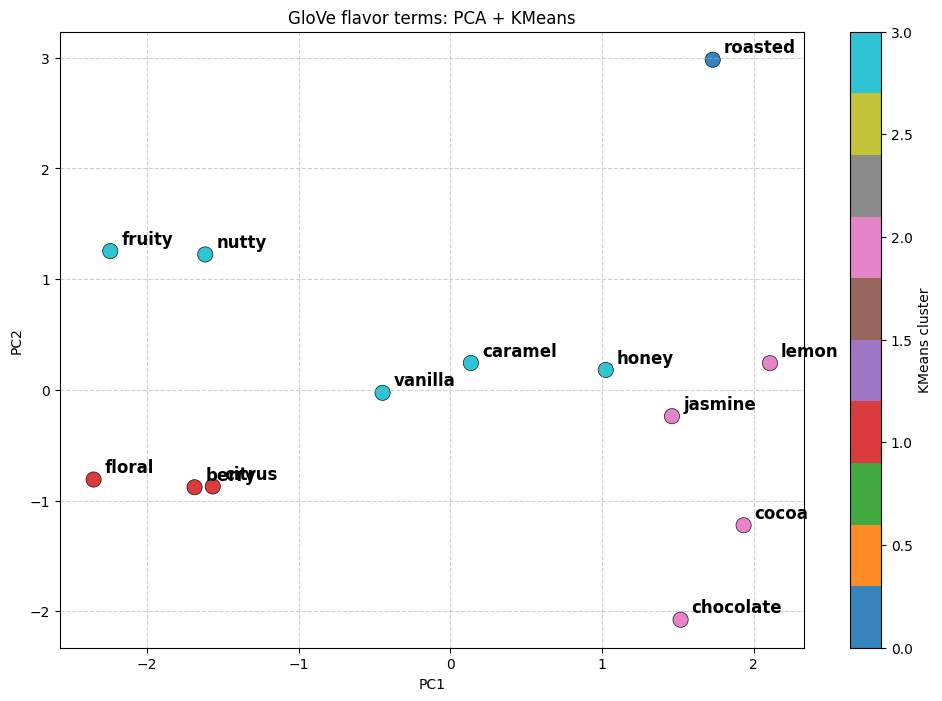

In [10]:
terms = existing_flavors
V = np.array([vectors[word2idx[w]] for w in terms])  # raw GloVe rows for PCA

pca = PCA(n_components=2)
coords_2d = pca.fit_transform(V)

n_clusters = min(4, max(2, len(terms) // 3))
labels = KMeans(n_clusters=n_clusters, random_state=42, n_init=10).fit_predict(V)
print("PCA explained variance ratio:", pca.explained_variance_ratio_)
print("Clusters:", list(zip(terms, labels)))

plt.figure(figsize=(12, 8))
sc = plt.scatter(
    coords_2d[:, 0], coords_2d[:, 1],
    c=labels, cmap="tab10", s=120,
    edgecolors="black", linewidths=0.5, alpha=0.9,
)
plt.colorbar(sc, label="KMeans cluster")
for i, word in enumerate(terms):
    plt.annotate(
        word, xy=(coords_2d[i, 0], coords_2d[i, 1]),
        xytext=(8, 5), textcoords="offset points", fontsize=12, fontweight="bold",
    )
plt.title("GloVe flavor terms: PCA + KMeans")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

## What to compare with Word2Vec

- **Neighbors / matrix / plot** will not match exactly: different objective (global log co-occurrence vs local prediction) and different random init.
- **Same preprocessing + min_count + window** keeps the experiment fair: same words enter both models.
- Read Pennington et al. (2014) alongside Mikolov et al. for skip-gram/CBOW to connect **paper → implementation → these plots**.

## Word2Vec vs GloVe (papers + this run)

See **`EMBEDDINGS_COMPARE.md`** in this folder for the full three-way write-up: Word2Vec vs GloVe vs FastText — what each approach **optimizes**, **captured outputs** on this corpus (neighbors, analogy, flavor pairs, PCA), and how to read differences without over-interpreting a small dataset.